This notebook analyzes the Libera science radiometer out of field measurements that were taken in the ERF facility. We used the same ERF light source used for the rest of the ERF calibrations, however we replaced the integrating sphere source with a 200 or 400um (TBR) multimode fiber. This generates a light source with an angular size less than 0.14 degrees. We then perform 1D yaw scans (cross-track direction) or 2D pitch and yaw scans over +/- 10 degrees and wavelengths from 0.36 um to 2.4 um.

In [1]:
import erf_scirad_scattered_light as erf_pst
import libera_telescope_pst as pst
import erf_analysis as erf
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import ipywidgets as widgets
import math
from IPython.display import display, Image

#from matplotlib.gridspec import GridSpec
#from types import SimpleNamespace
#from pathlib import Path

# The raw instrument data (ERF log files, laser spectra, MODTRAN scene files) is
# not in this repository - it is large and lives on LASP storage. Detected once
# here: the cells that re-reduce those files skip themselves with an explanation
# when it is absent, while everything downstream of the committed CSVs in data/
# runs either way. Set this False by hand to force the committed-CSV path even
# when the raw data is present.
raw_data_available = erf.raw_data_available()

The following code loads and plot some example data taken with the total channel at 359 nm.

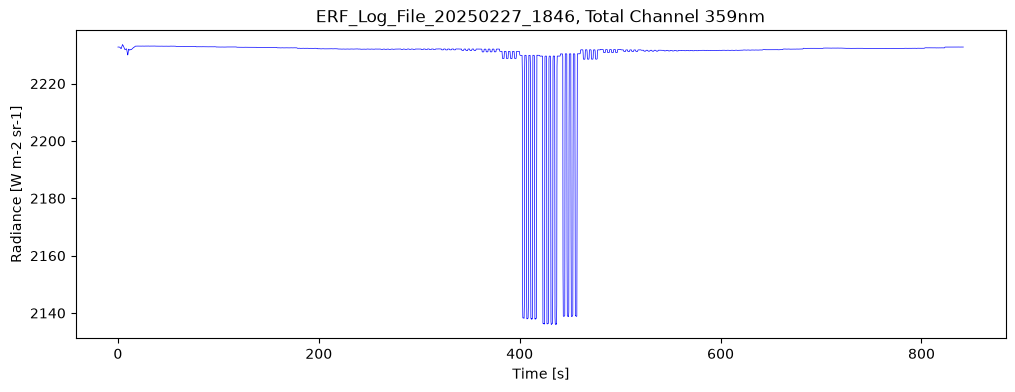

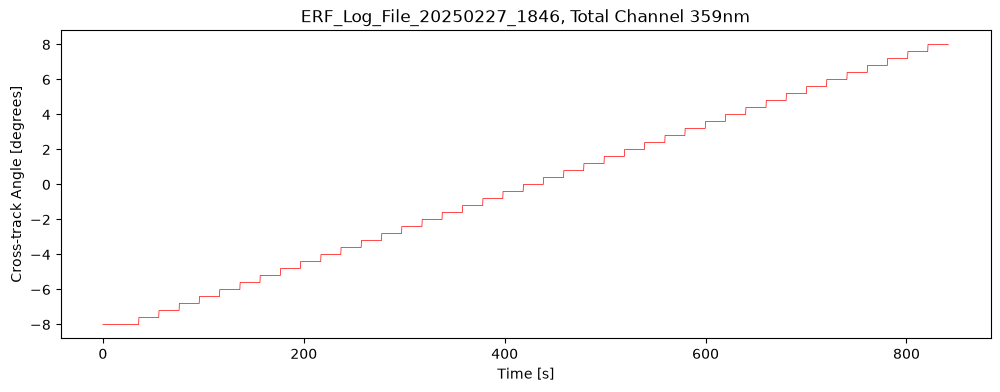

In [2]:
if raw_data_available:
    # Read in a Total channel, 359 nm scattered light measurement
    log_file = 'ERF_Log_File_20250227_1846'
    wavelength_um = 0.359
    df, pbr_conv = erf.load_erf_logfile(file=log_file + '.csv', wavelength_um=wavelength_um)

    df['time'] = df['gps_time_s'] - df['gps_time_s'].min()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df['time'], df['l1_to'], color='blue', linewidth=0.5)
    ax.set_title(f"{log_file}, Total Channel 359nm")
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Radiance [W m-2 sr-1]')

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df['time'], df['manip_yaw_deg'], color='red', linewidth=0.5)
    ax.set_title(f"{log_file}, Total Channel 359nm")
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Cross-track Angle [degrees]')

The next cell runs the analysis on all the ERF scattered light files and saves sumary files used for the later analysis.

In [3]:
# Collect every individual measurement point, before any radial averaging. The
# manipulator pitch and yaw are kept so that a cut can be applied per channel
# before averaging - the SW channel needs one, see the radial symmetry section.
analyze_erf_files = True

if analyze_erf_files and raw_data_available:
    data = erf_pst.batch_scirad_erf_scattered_light_store_all_measurements()

    # Sort by channel and wavelength
    data = data.sort_values(by=['detector_index', 'wavelength_um'])

    # Round wavelength to the nearest nm and add a wavenumber column
    data['wavelength_um'] = np.round(data['wavelength_um']*1000)/1000
    data['wavenum'] = 1e4/data['wavelength_um']

    ######################################
    # Detector Number Mapping 
    #
    #   Detector Index          Channel
    #       1                   SSW
    #       2                   LW, no scattered light data present for LW
    #       3                   Total
    #       4                   SW
    dss = data.loc[(data["detector_index"] == 1)].copy()
    dto = data.loc[(data["detector_index"] == 3)].copy()
    dsw = data.loc[(data["detector_index"] == 4)].copy()

    # Save the per-point data summary per channel
    paths = pst.load_config()
    filename = "scirad_ssw_pst_data.csv"
    dss.to_csv(paths.analysis_dir / filename, index=False, float_format='%.10g')

    filename = "scirad_total_pst_data.csv"
    dto.to_csv(paths.analysis_dir / filename, index=False, float_format='%.10g')

    filename = "scirad_sw_pst_data.csv"
    dsw.to_csv(paths.analysis_dir / filename, index=False, float_format='%.10g')
else:
    print("Skipped - regenerates:\n"
          "          data/scirad_ssw_pst_data.csv\n"
          "          data/scirad_total_pst_data.csv\n"
          "          data/scirad_sw_pst_data.csv\n"
          "          which are committed. The cells below read those files.")

Row Number: 0, Filename: ERF_Log_File_20250221_1606.csv
Row Number: 1, Filename: ERF_Log_File_20250221_1644.csv
Row Number: 2, Filename: ERF_Log_File_20250224_0930.csv
Row Number: 3, Filename: ERF_Log_File_20250224_0959.csv
Row Number: 4, Filename: ERF_Log_File_20250224_1022.csv
Row Number: 5, Filename: ERF_Log_File_20250224_1102.csv
Row Number: 6, Filename: ERF_Log_File_20250224_1129.csv
Row Number: 7, Filename: ERF_Log_File_20250224_1200.csv
Row Number: 8, Filename: ERF_Log_File_20250224_1231.csv
Row Number: 9, Filename: ERF_Log_File_20250224_1300.csv
Row Number: 10, Filename: ERF_Log_File_20250224_1326.csv
Row Number: 11, Filename: ERF_Log_File_20250224_1358.csv
Row Number: 12, Filename: ERF_Log_File_20250224_1425.csv
Row Number: 13, Filename: ERF_Log_File_20250224_1456.csv
Row Number: 14, Filename: ERF_Log_File_20250224_1519.csv
Row Number: 15, Filename: ERF_Log_File_20250224_1611.csv
Row Number: 16, Filename: ERF_Log_File_20250224_1634.csv
Row Number: 17, Filename: ERF_Log_File_20

## Measurement Uncertainty and the Noise Floor
We need an estimate of the noise floor. To obtain this we look for the radiance noise in the scans themselves. Specifically we look at the radiance noise for each dwell (every given pitch and yaw position), this is directly calculated as the standard deviation of the repeated shutter cycles at that position. We then calculate the mean radiance standard deviation for all measurements with a signal level below 1 W m-2 sr-1 for each telescope seperately.

Total Channel Noise: 0.00543 W m-2 sr-1
SSW Channel Noise:   0.00434 W m-2 sr-1
SW Channel Noise:    0.00942 W m-2 sr-1


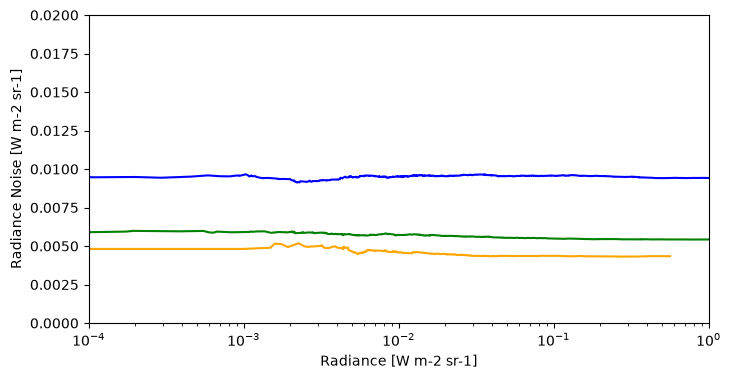

In [4]:
# This estimates the noise floor for each channel. This is done by looking at
# the mean value of l_sd for measurements with radiance below 1 W m-2 sr-1

# Load the data
paths = pst.load_config()
dto = erf_pst.tidy_up_header(pd.read_csv(paths.analysis_dir / "scirad_total_pst_data.csv"))
dss = erf_pst.tidy_up_header(pd.read_csv(paths.analysis_dir / "scirad_ssw_pst_data.csv"))
dsw = erf_pst.tidy_up_header(pd.read_csv(paths.analysis_dir / "scirad_sw_pst_data.csv"))

# Keep only data with radiance levels below 1 W m-2 sr-1
dto_tmp = dto.loc[(dto["l"] < 1)].copy()
dss_tmp = dss.loc[(dss["l"] < 1)].copy()
dsw_tmp = dsw.loc[(dsw["l"] < 1)].copy()

# Sort each by radiance
dto_tmp.sort_values(by='l', inplace=True)
dss_tmp.sort_values(by='l', inplace=True)
dsw_tmp.sort_values(by='l', inplace=True)

# Calculate the cumulative mean of the radiance standard deviation over the whole 
# dataset. The idea is that we can see the radiance noise at very low radiance levels
# that shows the radiance noise floor then see it creep up at higher radiance levels
dto_tmp['l_sd_cum'] = np.cumsum(dto_tmp['l_sd'])/np.arange(1, len(dto_tmp) + 1)
dss_tmp['l_sd_cum'] = np.cumsum(dss_tmp['l_sd'])/np.arange(1, len(dss_tmp) + 1)
dsw_tmp['l_sd_cum'] = np.cumsum(dsw_tmp['l_sd'])/np.arange(1, len(dsw_tmp) + 1)

# Plot this calcualted and modeled PSD
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(dto_tmp['l'], dto_tmp['l_sd_cum'], color='green')
ax.plot(dss_tmp['l'], dss_tmp['l_sd_cum'], color='orange')
ax.plot(dsw_tmp['l'], dsw_tmp['l_sd_cum'], color='blue')
ax.set_xlabel('Radiance [W m-2 sr-1]')
ax.set_ylabel('Radiance Noise [W m-2 sr-1]')
ax.set_xscale('log')
ax.set_ylim(0,0.02)
ax.set_xlim(1e-4,1)

print(f"Total Channel Noise: {dto_tmp['l_sd_cum'].iloc[-1]:.5f} W m-2 sr-1")
print(f"SSW Channel Noise:   {dss_tmp['l_sd_cum'].iloc[-1]:.5f} W m-2 sr-1")
print(f"SW Channel Noise:    {dsw_tmp['l_sd_cum'].iloc[-1]:.5f} W m-2 sr-1")

## 2D plots of the scattered light
Here we plot all the 2D out of field maps for the science radiometers. The out of field data also includes 1D scans at additional wavelengths.

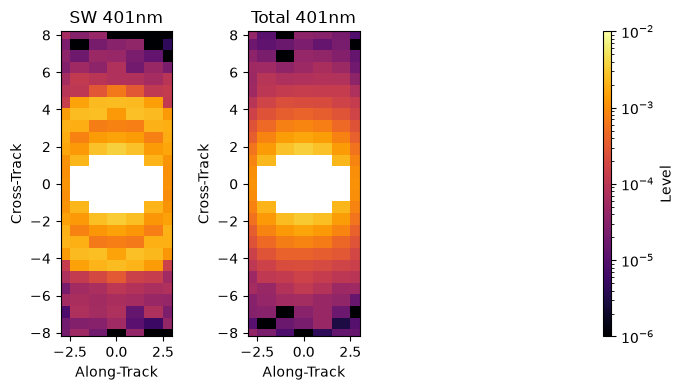

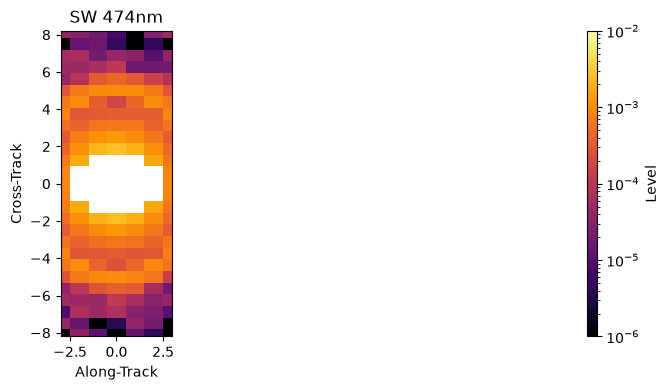

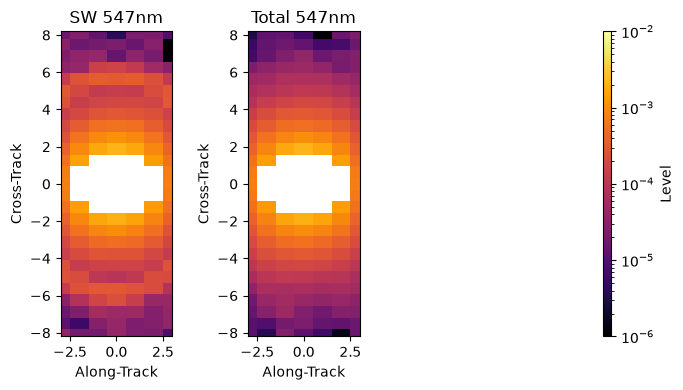

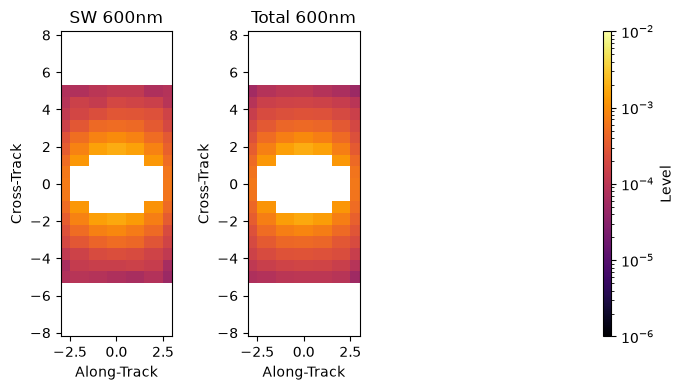

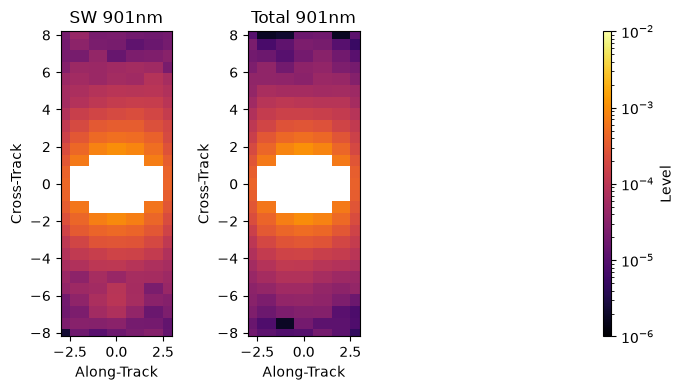

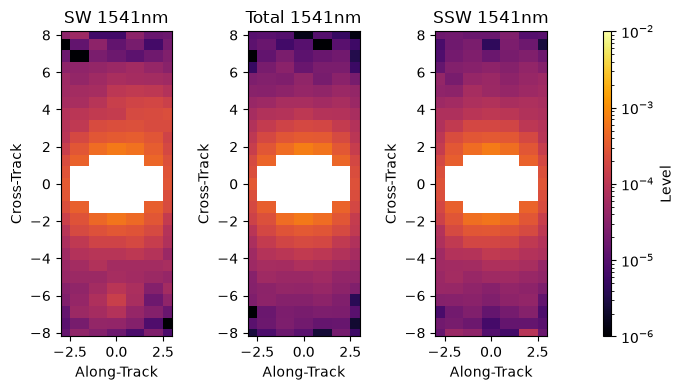

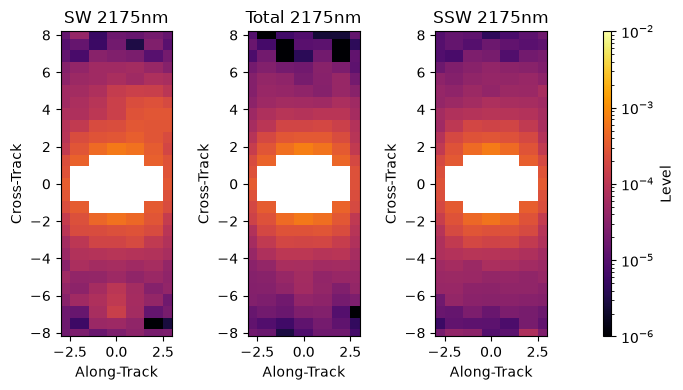

In [5]:
# Reload the data for the total channel
paths = pst.load_config()
dto = erf_pst.tidy_up_header(pd.read_csv(paths.analysis_dir / "scirad_total_pst_data.csv"))
dss = erf_pst.tidy_up_header(pd.read_csv(paths.analysis_dir / "scirad_ssw_pst_data.csv"))
dsw = erf_pst.tidy_up_header(pd.read_csv(paths.analysis_dir / "scirad_sw_pst_data.csv"))

# Keep only the 2D data
dto = dto.loc[(dto["type"] == "2d")]
dss = dss.loc[(dss["type"] == "2d")]
dsw = dsw.loc[(dsw["type"] == "2d")]

# Sort by wavelength
dto.sort_values('wavelength_um', inplace=True)
dss.sort_values('wavelength_um', inplace=True)
dsw.sort_values('wavelength_um', inplace=True)

# Get the wavelengths for each channel
wavelengths_um_to = dto['wavelength_um'].unique()
wavelengths_um_ss = dss['wavelength_um'].unique()
wavelengths_um_sw = dsw['wavelength_um'].unique()

vmin = 1e-6
vmax = 1e-2

xmin = -3
xmax =  3

ymin = -8.2
ymax =  8.2

# Plotting floor. The wings run into the noise, so a good fraction of those
# points come out negative, and a log scale cannot show them - they drop out as
# blank cells. Parking them one decade below vmin renders them at the bottom of
# the colour scale instead. This is for display only: nothing downstream of this
# cell uses it, and the fits work off the signed values.
plot_floor = 1e-7

# One shared norm for every map and for the colorbar. Building it once, rather
# than passing norm='log' with vmin/vmax to each pcolormesh, means the colorbar
# no longer depends on which panel happened to draw last - which varies by
# wavelength, since not every channel has data at every wavelength.
norm = mpl.colors.LogNorm(vmin=vmin, vmax=vmax)

# The three panels differ only in name and dataframe
panels = [('SW',    dsw, wavelengths_um_sw),
          ('Total', dto, wavelengths_um_to),
          ('SSW',   dss, wavelengths_um_ss)]

# Loop through each wavelength
for wl in wavelengths_um_sw:

    # Three maps plus a narrow fourth column that holds only the colorbar
    fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(7, 4), width_ratios=[1, 1, 1, 0.3])

    for a, (name, d, wavelengths_um) in zip(ax, panels):

        # Channels with no data at this wavelength drop out entirely.
        # set_visible hides the frame, ticks and title together; set_axis_off
        # would leave the title floating over an empty panel.
        if wl not in wavelengths_um:
            a.set_visible(False)
            continue

        d_tmp = d.loc[(d["wavelength_um"] == wl)].copy()
        t = d_tmp.pivot_table(index="manip_yaw_deg", columns="manip_pitch_deg",
                              values="signal", aggfunc='mean')

        # mask() rather than where(): the condition is False for NaN, so grid
        # positions that were never visited stay NaN and keep rendering blank,
        # while only the genuinely non-positive points get floored.
        t = t.mask(t <= 0, plot_floor)
        a.pcolormesh(t.columns.values, t.index.values, t.values,
                     norm=norm, cmap='inferno', shading='nearest')
        a.set_xlim(xmin, xmax)
        a.set_ylim(ymin, ymax)
        a.set_xlabel("Along-Track")
        a.set_ylabel("Cross-Track")
        a.set_title(f"{name} {round(wl*1000)}nm")
        a.set_aspect('equal') 

    # Fourth column carries the colorbar only: blank the placeholder axes, then
    # carve the bar out of its slot with inset_axes ([left, bottom, width, height]
    # in axes fraction, so the third number sets the bar width).
    ax[3].set_axis_off()
    cax = ax[3].inset_axes([0.0, 0.0, 0.18, 1.0])
    cb = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap='inferno'),
                      cax=cax, label='Level')

    fig.tight_layout()


## Total Channel Analysis
Here we perform the global fit to all the total channel data (across angle and wavelength). This model included diffraction from the spiders & secondary (which is small in the SW), and surface and particulate scatter from the primary mirror. The surface scatter dominates the signal below ~700nm, and then the particulate scatter dominates at longer wavelength.

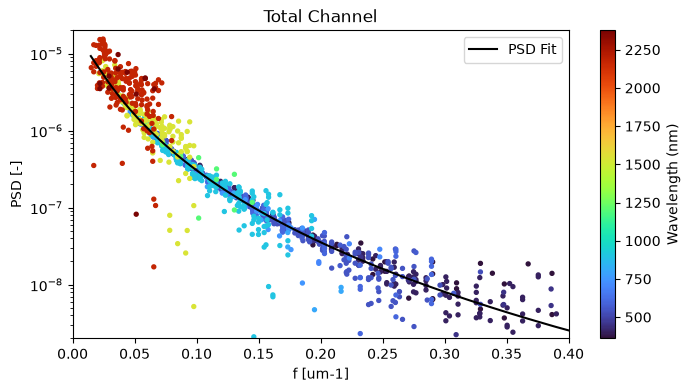

In [6]:
# Reload the data for the total channel
paths = pst.load_config()
dto = erf_pst.tidy_up_header(pd.read_csv(paths.analysis_dir / "scirad_total_pst_data.csv"))

# Fit the data
rto = erf_pst.scirad_pst_two_component_fitting(meas_data=dto)
fit_to = rto.result

# Get the fit coeffs
a0  = fit_to.best_values['a0']
a1  = fit_to.best_values['a1']
a2  = fit_to.best_values['a2']
lp0 = fit_to.best_values['lp0']
lp1 = fit_to.best_values['lp1']

# Calculate the fit and get the relative components
d = pst.pst_two_components(dto["rad_angle_deg"], dto['wavelength_um'], a0, a1, a2, lp0, lp1)

dto['fit_f']        = d.f
dto['fit_psd']      = d.psd
dto['fit_pst']      = d.pst
dto['fit_pst_surf'] = d.surf
dto['fit_pst_part'] = d.part
dto['fit_pst_diff'] = d.diff
dto['fit_pst_geo']  = d.geo_factor

######
# I want to calculate the PSD from the data by removing the other corrections
#
# geo_factor*(pst_surf + pst_part) + pst_diff = pst_total
# geo_factor*(pst_surf + pst_part) = pst_total - pst_diff
# pst_surf + pst_part = (pst_total - pst_diff)/geo_factor
# pst_surf = (pst_total - pst_diff)/geo_factor - pst_part
#
# pst_surf = psd * 16.0 * math.pi**2 / wavelength_um**4
# 
# psd * 16.0 * math.pi**2 / wavelength_um**4 = (pst_total - pst_diff)/geo_factor - pst_part
#
# psd = (wavelength_um**4)*((pst_total - pst_diff)/geo_factor - pst_part)/(16.0 * math.pi**2)
#

dto['f'] = np.sin(np.radians(dto["rad_angle_deg"]))/dto['wavelength_um']
dto['psd'] = (dto['wavelength_um']**4)*((dto['signal'] - dto['fit_pst_diff'])/dto['fit_pst_geo'] - dto['fit_pst_part'])/(16.0 * math.pi**2)

# Plot this calcualted and modeled PSD
fig, ax = plt.subplots(figsize=(8, 4))

sc1 = ax.scatter(dto["f"], dto["psd"], c=1000*dto["wavelength_um"], cmap='turbo', s=8, zorder=1)
dto.sort_values(by='f',inplace=True)
ax.plot(dto["f"], dto["fit_psd"], color='black', zorder=2, label='PSD Fit')
ax.set_title('Total Channel')
ax.set_xlabel('f [um-1]')
ax.set_ylabel('PSD [-]')
ax.set_yscale('log')
ax.set_xlim(0, 0.4)
ax.set_ylim(2e-9, 2e-5)
ax.legend()
cb = fig.colorbar(sc1, ax=ax, label='Wavelength (nm)')


Next we plot the resultant global fit with the data at each wavelength.

 wavelength_um  n_pts  l_max
        0.3600     52 0.3315
        0.4010    188 1.3261
        0.4500     20 1.2156
        0.5280     20 1.5179
        0.5470    286 1.5074
        0.5650     20 1.2749
        0.6000    158 1.1438
        0.7010     20 1.0759
        0.7510     32 1.1293
        0.8020     20 1.0177
        0.9010    208 0.8797
        1.1990     20 0.5434
        1.5410    168 0.6075
        2.1750    188 0.6211
        2.3760     20 0.1643


IntSlider(value=0, description='Plot', max=14)

Output()

[[Model]]
    Model(pst_two_component_fit_fn)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 43
    # data points      = 1420
    # variables        = 5
    chi-square         = 1182.28441
    reduced chi-square = 0.83553668
    Akaike info crit   = -250.155881
    Bayesian info crit = -223.863820
    R-squared          = 0.99056532
[[Variables]]
    a0:  -14.4114540 +/- 0.00768047 (0.05%) (init = -14.39)
    a1:  -2.52677245 +/- 0.01579016 (0.62%) (init = -2.53)
    a2:  -0.50682109 +/- 0.01971530 (3.89%) (init = -0.37)
    lp0: -10.3075679 +/- 0.03658702 (0.35%) (init = -10.58)
    lp1: -2.98631944 +/- 0.03082738 (1.03%) (init = -3.14)
[[Correlations]] (unreported correlations are < 0.100)
    C(lp0, lp1) = +0.8869
    C(a1, a2)   = -0.7193
    C(a0, lp0)  = -0.7169
    C(a0, lp1)  = -0.6559
    C(a1, lp0)  = +0.4896
    C(a0, a1)   = -0.3960
    C(a2, lp0)  = -0.3408
    C(a1, lp1)  = +0.1785


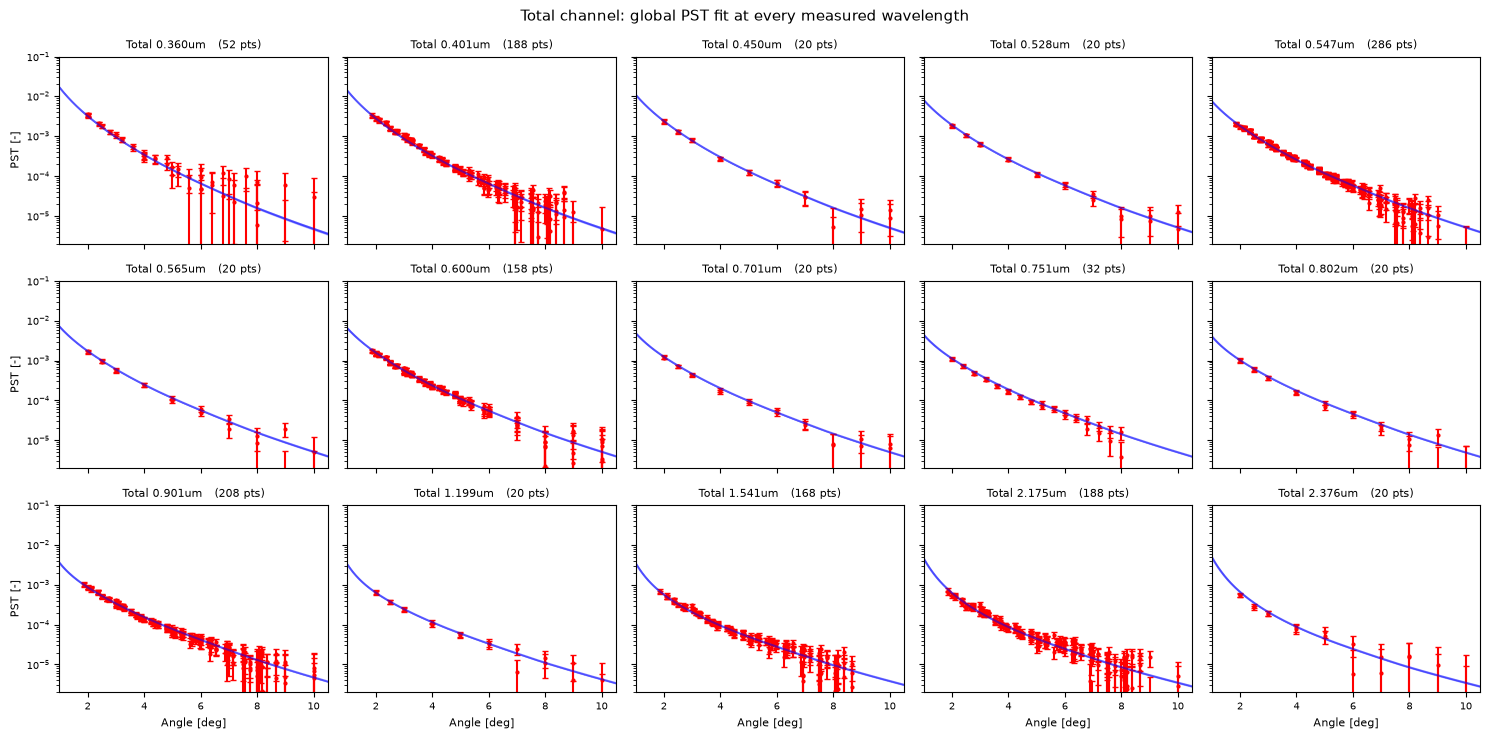

In [7]:
# Per-wavelength view of the global fit. The same panel_fn draws both the
# flipbook frames and the grid figure, so the two cannot drift apart - see
# erf_scirad_scattered_light.pst_fit_panels. The grid is the version that
# renders without a live kernel, i.e. the one visible on GitHub.
dto.sort_values(by="wavelength_um", inplace=True)
wavelengths_um = dto['wavelength_um'].unique()

# The angle array for fitting
angle_deg_fit = np.linspace(1,20,500)


def panel(ax, wl):
    # Get the data at this wavelength
    dtmp = dto.loc[(dto['wavelength_um'] == wl)].copy()
    wavelength_um = dtmp['wavelength_um'].median()

    # Calculate the fit and its uncertainty
    fit    = fit_to.eval(angle_deg=angle_deg_fit, wavelength_um=wavelength_um)
    fit_sd = fit_to.eval_uncertainty(angle_deg=angle_deg_fit, wavelength_um=wavelength_um)

    # Plot the fit
    ax.fill_between(angle_deg_fit, fit - fit_sd, fit + fit_sd, color='blue', alpha=0.3, zorder=1)
    ax.plot(angle_deg_fit, fit, color='blue', zorder=2, alpha=0.5)
    ax.errorbar(dtmp["rad_angle_deg"], dtmp["signal"], yerr=dtmp["signal_uc"],
        fmt='o', color='red', markersize=2, capsize=2, zorder=1)
    ax.set_title(f"Total {wl:4.3f}um   ({len(dtmp)} pts)")
    ax.set_xlim(1,10.5)
    ax.set_ylim(2e-6,0.1)
    ax.set_yscale('log')

    return {"n_pts": len(dtmp), "l_max": dtmp['l'].max()}


series = erf_pst.pst_fit_panels(
    panel_fn       = panel,
    wavelengths_um = wavelengths_um,
    figure_dir     = paths.figure_dir,
    name_fmt       = "scirad_total_pst_global_fit_{nm}nm.png",
    grid_name      = "scirad_total_pst_global_fit_grid.png",
    suptitle       = "Total channel: global PST fit at every measured wavelength")

print(series.summary.to_string(index=False,
                               float_format=lambda v: f"{v:.4f}"))
erf_pst.flipbook(series.plots)

print(fit_to.fit_report())

,wavelength_um,loss_10,loss_10_sd,loss_12,loss_12_sd,loss_13,loss_13_sd
0,0.250000,3.418446,0.041927,2.471013,0.036149,1.919447,0.032609
1,0.252025,3.403233,0.041345,2.463029,0.035623,1.914908,0.032137
2,0.254066,3.387911,0.040772,2.454938,0.035105,1.910273,0.031669
3,0.256124,3.372480,0.040207,2.446740,0.034593,1.905545,0.031207
4,0.258198,3.356943,0.039650,2.438438,0.034088,1.900724,0.030751


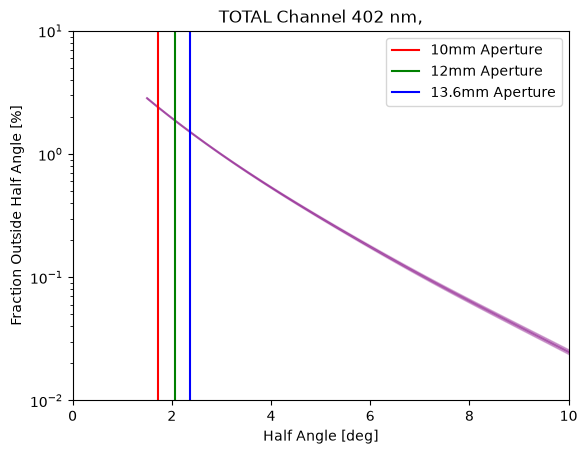

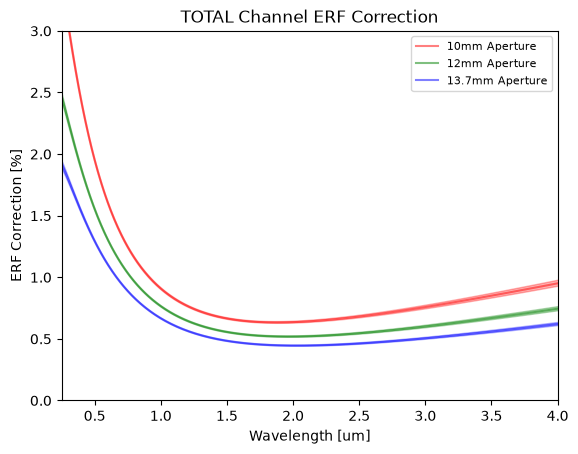

In [8]:
# Out-of-field loss vs wavelength for the total channel.
#
# The calculation is the same for every channel, so it lives in
# erf_scirad_scattered_light.scirad_erf_correction rather than being repeated
# here: integrate the fitted PST over annular rings, add the in-field solid
# angle, and report the fraction falling outside each aperture half angle.

loss_summary = erf_pst.scirad_erf_correction(
    fit_result         = fit_to,
    channel            = 'total',
    wavelength_um_min  = 0.25,
    wavelength_um_max  = 14,
    plot_wavelength_um = 0.4,
    summary_filename   = "scirad_total_pst_corr.csv")

loss_summary.head()

## SSW Channel Analysis
Here we perform the global fit to all the SSW channel data (across angle and wavelength). This model included diffraction from the spiders & secondary (which is small in the SW), and surface and particulate scatter from the primary mirror. Since the SSW channel range starts only at ~700nm the scatter is quite small.

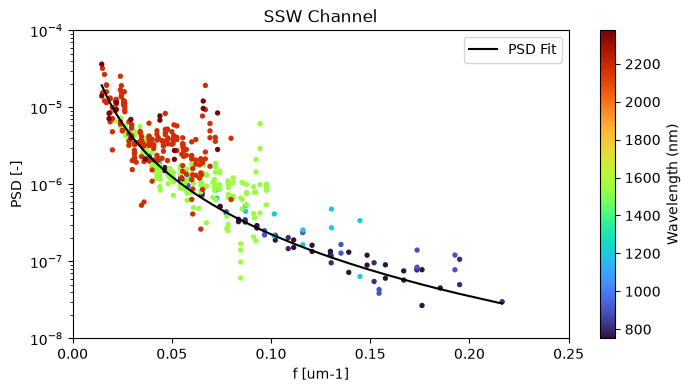

In [9]:
# Reload the data for the SSW channel
paths = pst.load_config()
dss = erf_pst.tidy_up_header(pd.read_csv(paths.analysis_dir / "scirad_ssw_pst_data.csv"))

# Fit the data
rss = erf_pst.scirad_pst_two_component_fitting(meas_data=dss)
fit_ss = rss.result

# Get the fit coeffs
a0  = fit_ss.best_values['a0']
a1  = fit_ss.best_values['a1']
a2  = fit_ss.best_values['a2']
lp0 = fit_ss.best_values['lp0']
lp1 = fit_ss.best_values['lp1']

# Calculate the fit and get the relative components
d = pst.pst_two_components(dss["rad_angle_deg"], dss['wavelength_um'], a0, a1, a2, lp0, lp1)

dss['fit_f']        = d.f
dss['fit_psd']      = d.psd
dss['fit_pst']      = d.pst
dss['fit_pst_surf'] = d.surf
dss['fit_pst_part'] = d.part
dss['fit_pst_diff'] = d.diff
dss['fit_pst_geo']  = d.geo_factor

######
# I want to calculate the PSD from the data by removing the other corrections
#
# geo_factor*(pst_surf + pst_part) + pst_diff = pst_total
# geo_factor*(pst_surf + pst_part) = pst_total - pst_diff
# pst_surf + pst_part = (pst_total - pst_diff)/geo_factor
# pst_surf = (pst_total - pst_diff)/geo_factor - pst_part
#
# pst_surf = psd * 16.0 * math.pi**2 / wavelength_um**4
# 
# psd * 16.0 * math.pi**2 / wavelength_um**4 = (pst_total - pst_diff)/geo_factor - pst_part
#
# psd = (wavelength_um**4)*((pst_total - pst_diff)/geo_factor - pst_part)/(16.0 * math.pi**2)
#

dss['f'] = np.sin(np.radians(dss["rad_angle_deg"]))/dss['wavelength_um']
dss['psd'] = (dss['wavelength_um']**4)*((dss['signal'] - dss['fit_pst_diff'])/dss['fit_pst_geo'] - dss['fit_pst_part'])/(16.0 * math.pi**2)

# Plot this calcualted and modeled PSD
fig, ax = plt.subplots(figsize=(8, 4))

sc1 = ax.scatter(dss["f"], dss["psd"], c=1000*dss["wavelength_um"], cmap='turbo', s=8, zorder=1)
dss.sort_values(by='f',inplace=True)
ax.plot(dss["f"], dss["fit_psd"], color='black', zorder=2, label='PSD Fit')
ax.set_title('SSW Channel')
ax.set_xlabel('f [um-1]')
ax.set_ylabel('PSD [-]')
ax.set_yscale('log')
ax.set_xlim(0, 0.25)
ax.set_ylim(1e-8, 1e-4)
ax.legend()
cb = fig.colorbar(sc1, ax=ax, label='Wavelength (nm)')

Next we plot the resultant global fit with the data at each wavelength.

 wavelength_um  n_pts  l_max
        0.7510     32 0.3982
        0.8020     20 0.5640
        0.9010     20 0.4388
        1.1990     20 0.3706
        1.5410    168 0.4045
        2.1750    188 0.4068
        2.3760     20 0.1164


IntSlider(value=0, description='Plot', max=6)

Output()

[[Model]]
    Model(pst_two_component_fit_fn)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 67
    # data points      = 468
    # variables        = 5
    chi-square         = 554.132136
    reduced chi-square = 1.19682967
    Akaike info crit   = 89.0615214
    Bayesian info crit = 109.803863
    R-squared          = 0.98542490
[[Variables]]
    a0:  -14.7335457 +/- 0.05332472 (0.36%) (init = -14.39)
    a1:  -2.52012834 +/- 0.07267086 (2.88%) (init = -2.53)
    a2:  -0.13464161 +/- 0.10655016 (79.14%) (init = -0.37)
    lp0: -9.68028798 +/- 0.05017447 (0.52%) (init = -10.58)
    lp1: -2.30397654 +/- 0.07250124 (3.15%) (init = -3.14)
[[Correlations]] (unreported correlations are < 0.100)
    C(a0, lp0)  = -0.8353
    C(lp0, lp1) = +0.8021
    C(a0, lp1)  = -0.7887
    C(a2, lp1)  = +0.7684
    C(a0, a2)   = -0.5639
    C(a2, lp0)  = +0.4847
    C(a1, a2)   = +0.2714
    C(a0, a1)   = +0.2169
    C(a1, lp1)  = -0.1875


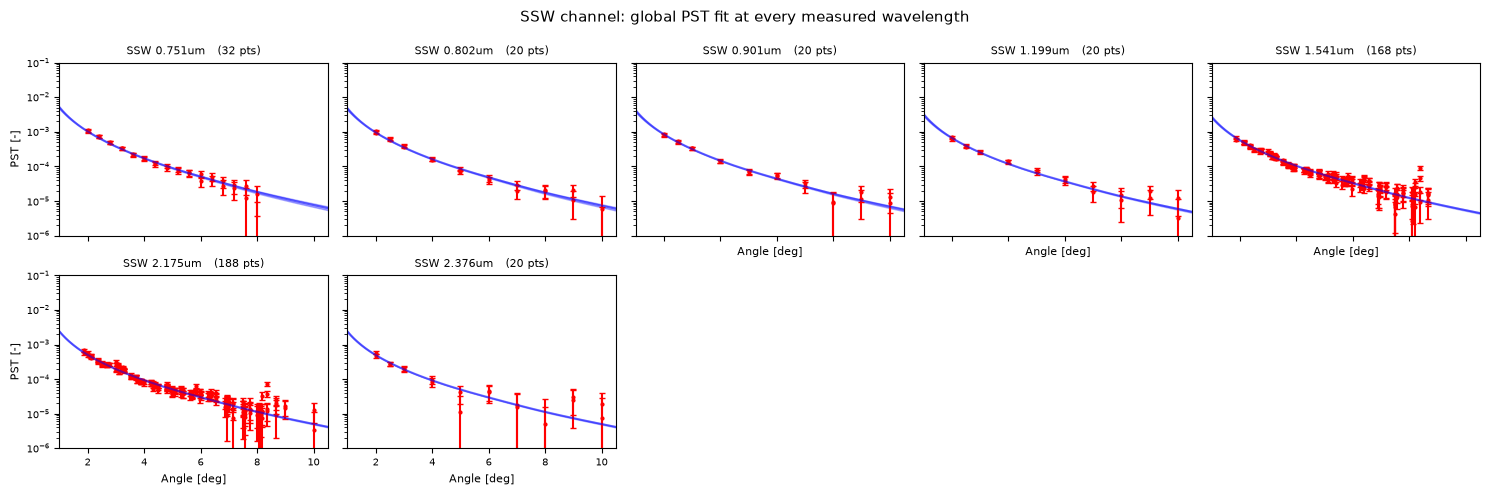

In [10]:
# Per-wavelength view of the global fit. The same panel_fn draws both the
# flipbook frames and the grid figure, so the two cannot drift apart - see
# erf_scirad_scattered_light.pst_fit_panels. The grid is the version that
# renders without a live kernel, i.e. the one visible on GitHub.
dss.sort_values(by="wavelength_um", inplace=True)
wavelengths_um = dss['wavelength_um'].unique()

# The angle array for fitting
angle_deg_fit = np.linspace(1,20,500)


def panel(ax, wl):
    # Get the data at this wavelength
    dtmp = dss.loc[(dss['wavelength_um'] == wl)].copy()
    wavelength_um = dtmp['wavelength_um'].median()

    # Calculate the fit and its uncertainty
    fit    = fit_ss.eval(angle_deg=angle_deg_fit, wavelength_um=wavelength_um)
    fit_sd = fit_ss.eval_uncertainty(angle_deg=angle_deg_fit, wavelength_um=wavelength_um)

    # Plot the fit
    ax.fill_between(angle_deg_fit, fit - fit_sd, fit + fit_sd, color='blue', alpha=0.3, zorder=1)
    ax.plot(angle_deg_fit, fit, color='blue', zorder=2, alpha=0.5)
    ax.errorbar(dtmp["rad_angle_deg"], dtmp["signal"], yerr=dtmp["signal_uc"],
        fmt='o', color='red', markersize=2, capsize=2, zorder=1)
    ax.set_title(f"SSW {wl:4.3f}um   ({len(dtmp)} pts)")
    ax.set_xlim(1,10.5)
    ax.set_ylim(1e-6,0.1)
    ax.set_yscale('log')

    return {"n_pts": len(dtmp), "l_max": dtmp['l'].max()}


series = erf_pst.pst_fit_panels(
    panel_fn       = panel,
    wavelengths_um = wavelengths_um,
    figure_dir     = paths.figure_dir,
    name_fmt       = "scirad_ssw_pst_global_fit_{nm}nm.png",
    grid_name      = "scirad_ssw_pst_global_fit_grid.png",
    suptitle       = "SSW channel: global PST fit at every measured wavelength")

print(series.summary.to_string(index=False,
                               float_format=lambda v: f"{v:.4f}"))
erf_pst.flipbook(series.plots)

print(fit_ss.fit_report())

,wavelength_um,loss_10,loss_10_sd,loss_12,loss_12_sd,loss_13,loss_13_sd
0,0.650000,1.392017,0.066032,1.159264,0.059295,1.005843,0.054759
1,0.652902,1.385802,0.065309,1.154278,0.058633,1.001637,0.054143
2,0.655816,1.379625,0.064594,1.149322,0.057979,0.997456,0.053535
3,0.658744,1.373486,0.063887,1.144395,0.057331,0.993299,0.052933
4,0.661684,1.367386,0.063188,1.139498,0.056691,0.989166,0.052337


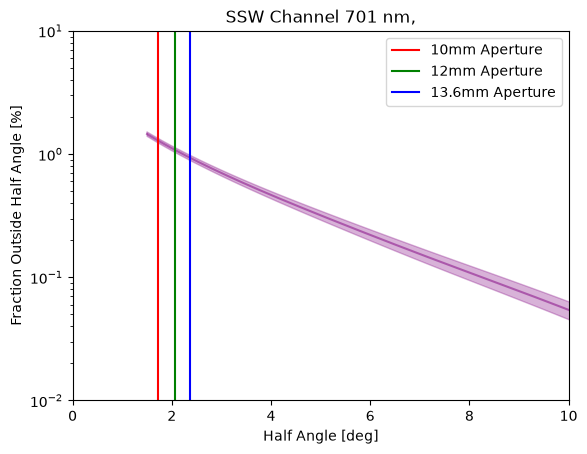

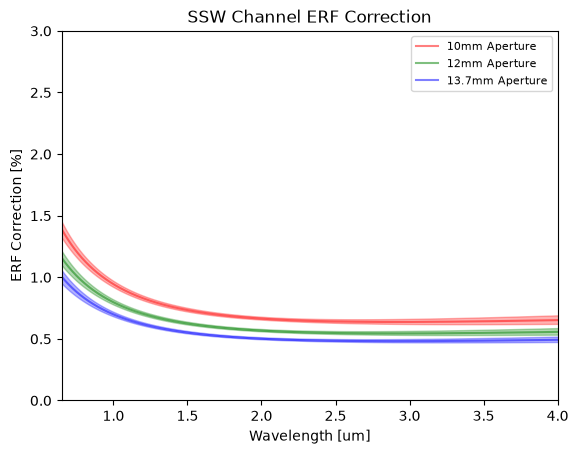

In [11]:
# Out-of-field loss vs wavelength for the ssw channel.
#
# The calculation is the same for every channel, so it lives in
# erf_scirad_scattered_light.scirad_erf_correction rather than being repeated
# here: integrate the fitted PST over annular rings, add the in-field solid
# angle, and report the fraction falling outside each aperture half angle.

loss_summary = erf_pst.scirad_erf_correction(
    fit_result         = fit_ss,
    channel            = 'ssw',
    wavelength_um_min  = 0.65,
    wavelength_um_max  = 6,
    plot_wavelength_um = 0.7,
    summary_filename   = "scirad_ssw_pst_corr.csv")

loss_summary.head()

## SW Channel Analysis
Here we perform the global fit to all the SW channel data (across angle and wavelength). This model included diffraction from the spiders & secondary (which is small in the SW), and surface and particulate scatter from the primary mirror as well as a annulus that appears to be caused by diffraction from the front-surface of the secondary back-reflecting off the fused silica filter.

redchi = 1.782,  aic = 835.3
ring centre spacing gc0 = 5.3837 +/- 0.0071 um


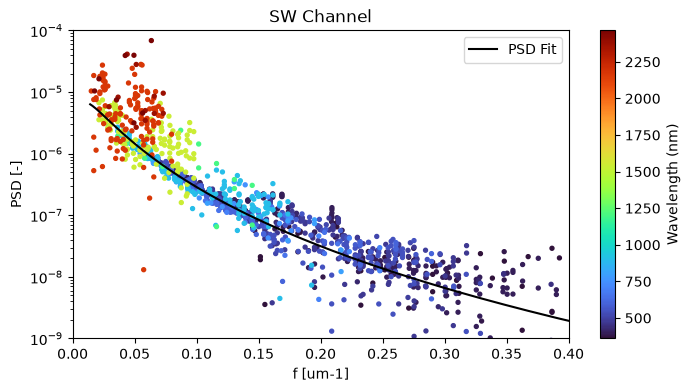

In [12]:
# Reload the data for the SW channel
paths = pst.load_config()
dsw = erf_pst.tidy_up_header(pd.read_csv(paths.analysis_dir / "scirad_sw_pst_data.csv"))

# Throw out the one point beyond 2.4um which has very low SNR and doesn't help the global fit
# dsw_pts = dsw_pts.loc[(dsw_pts["wavelength_um"] < 2.4)]

# Mask the +yaw feature ("the blob") before averaging. Its origin could not be
# established, so it is treated as an artifact of the calibration setup: removed
# here to give an uncontaminated baseline model, with its integrated
# contribution carried instead as an uncertainty on the ERF correction below.
# The cut is on +yaw at all pitch - the feature reaches pitch 0 and -1, so a
# pitch-only cut leaves a residue - and costs 16.5% of the points.
dsw_unmasked = dsw.copy()   # kept for the blob integral below
dsw = erf_pst.apply_blob_mask(dsw)

# Fit the data
rsw = erf_pst.scirad_pst_three_component_fitting(meas_data=dsw)
fit_sw = rsw.result

# Get the fit coeffs
a0  = fit_sw.best_values['a0']
a1  = fit_sw.best_values['a1']
a2  = fit_sw.best_values['a2']
lp0 = fit_sw.best_values['lp0']
lp1 = fit_sw.best_values['lp1']
gc0 = fit_sw.best_values['gc0']
gw0 = fit_sw.best_values['gw0']
gw1 = fit_sw.best_values['gw1']
ga0 = fit_sw.best_values['ga0']
ga1 = fit_sw.best_values['ga1']

# Calculate the fit and get the relative components
d = pst.pst_three_components(dsw["rad_angle_deg"], dsw['wavelength_um'],
                             a0, a1, a2, lp0, lp1, gc0, gw0, gw1, ga0, ga1)

dsw['fit_f']        = d.f
dsw['fit_psd']      = d.psd
dsw['fit_pst']      = d.pst
dsw['fit_pst_surf'] = d.surf
dsw['fit_pst_part'] = d.part
dsw['fit_pst_diff'] = d.diff
dsw['fit_pst_ring'] = d.ring
dsw['fit_pst_geo']  = d.geo_factor

######
# Same PSD back-calculation as the other channels, with the ring removed too.
# The ring sits outside the geometric factor, like the diffraction term.
#
# geo_factor*(pst_surf + pst_part) + pst_diff + pst_ring = pst_total
# geo_factor*(pst_surf + pst_part) = pst_total - pst_diff - pst_ring
# pst_surf + pst_part = (pst_total - pst_diff - pst_ring)/geo_factor
# pst_surf = (pst_total - pst_diff - pst_ring)/geo_factor - pst_part
#
# pst_surf = psd * 16.0 * math.pi**2 / wavelength_um**4
#
# psd = (wavelength_um**4)*((pst_total - pst_diff - pst_ring)/geo_factor - pst_part)/(16.0 * math.pi**2)
#

dsw['f'] = np.sin(np.radians(dsw["rad_angle_deg"]))/dsw['wavelength_um']
dsw['psd'] = (dsw['wavelength_um']**4)*((dsw['signal'] - dsw['fit_pst_diff'] - dsw['fit_pst_ring'])/dsw['fit_pst_geo'] - dsw['fit_pst_part'])/(16.0 * math.pi**2)

# Plot this calcualted and modeled PSD
fig, ax = plt.subplots(figsize=(8, 4))

sc1 = ax.scatter(dsw["f"], dsw["psd"], c=1000*dsw["wavelength_um"], cmap='turbo', s=8, zorder=1)
dsw.sort_values(by='f',inplace=True)
ax.plot(dsw["f"], dsw["fit_psd"], color='black', zorder=2, label='PSD Fit')
ax.set_title('SW Channel')
ax.set_xlabel('f [um-1]')
ax.set_ylabel('PSD [-]')
ax.set_yscale('log')
ax.set_xlim(0, 0.4)
ax.set_ylim(1e-9, 1e-4)
ax.legend()
cb = fig.colorbar(sc1, ax=ax, label='Wavelength (nm)')

print(f"redchi = {rsw.redchi:.3f},  aic = {rsw.aic:.1f}")
print(f"ring centre spacing gc0 = {rsw.gc0:.4f} +/- {rsw.gc0_sd:.4f} um")

Next we plot the resultant global fit with the data at each wavelength. The dashed lines break the model into the scatter plus diffraction background and the secondary annulus, which dominates near 4-6 degrees at the shortest wavelengths and fades away by ~700 nm.

 wavelength_um  n_pts  l_max
        0.3600     74 0.3575
        0.3800     32 0.4838
        0.4010    188 1.1997
        0.4250     32 0.9754
        0.4500     20 1.0639
        0.4740    168 0.7151
        0.4890     32 0.9309
        0.5110     21 0.7751
        0.5280     14 1.2393
        0.5470    203 1.2941
        0.5650     14 1.0217
        0.5800     21 0.7536
        0.6000     91 0.9261
        0.6510     21 0.7364
        0.7010     14 0.8562
        0.7510     21 0.8785
        0.8020     14 0.7645
        0.9010    140 0.7175
        1.1990     14 0.4061
        1.5410    126 0.5106
        2.1750    140 0.4927
        2.3760     14 0.1235
        2.4640     14 0.0180


IntSlider(value=0, description='Plot', max=22)

Output()

[[Model]]
    Model(pst_three_component_fit_fn)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 78
    # data points      = 1428
    # variables        = 10
    chi-square         = 2527.45080
    reduced chi-square = 1.78240536
    Akaike info crit   = 835.297099
    Bayesian info crit = 887.937400
    R-squared          = 0.96721822
[[Variables]]
    a0:  -14.4768772 +/- 0.01599466 (0.11%) (init = -14.51)
    a1:  -2.49653605 +/- 0.03222505 (1.29%) (init = -2.37)
    a2:  -0.60545168 +/- 0.05545226 (9.16%) (init = -0.57)
    lp0: -9.80702776 +/- 0.06264745 (0.64%) (init = -9.46)
    lp1: -2.55207471 +/- 0.05125313 (2.01%) (init = -2.45)
    gc0:  5.38373078 +/- 0.00714282 (0.13%) (init = 5.41)
    gw0: -0.99384955 +/- 0.01412628 (1.42%) (init = -1.06)
    gw1: -0.12674096 +/- 0.22775984 (179.70%) (init = 1.33)
    ga0: -6.50558939 +/- 0.01955362 (0.30%) (init = -6.5)
    ga1: -16.0736790 +/- 0.31465870 (1.96%) (init = -15.9)
[[Correlations]] (unreported c

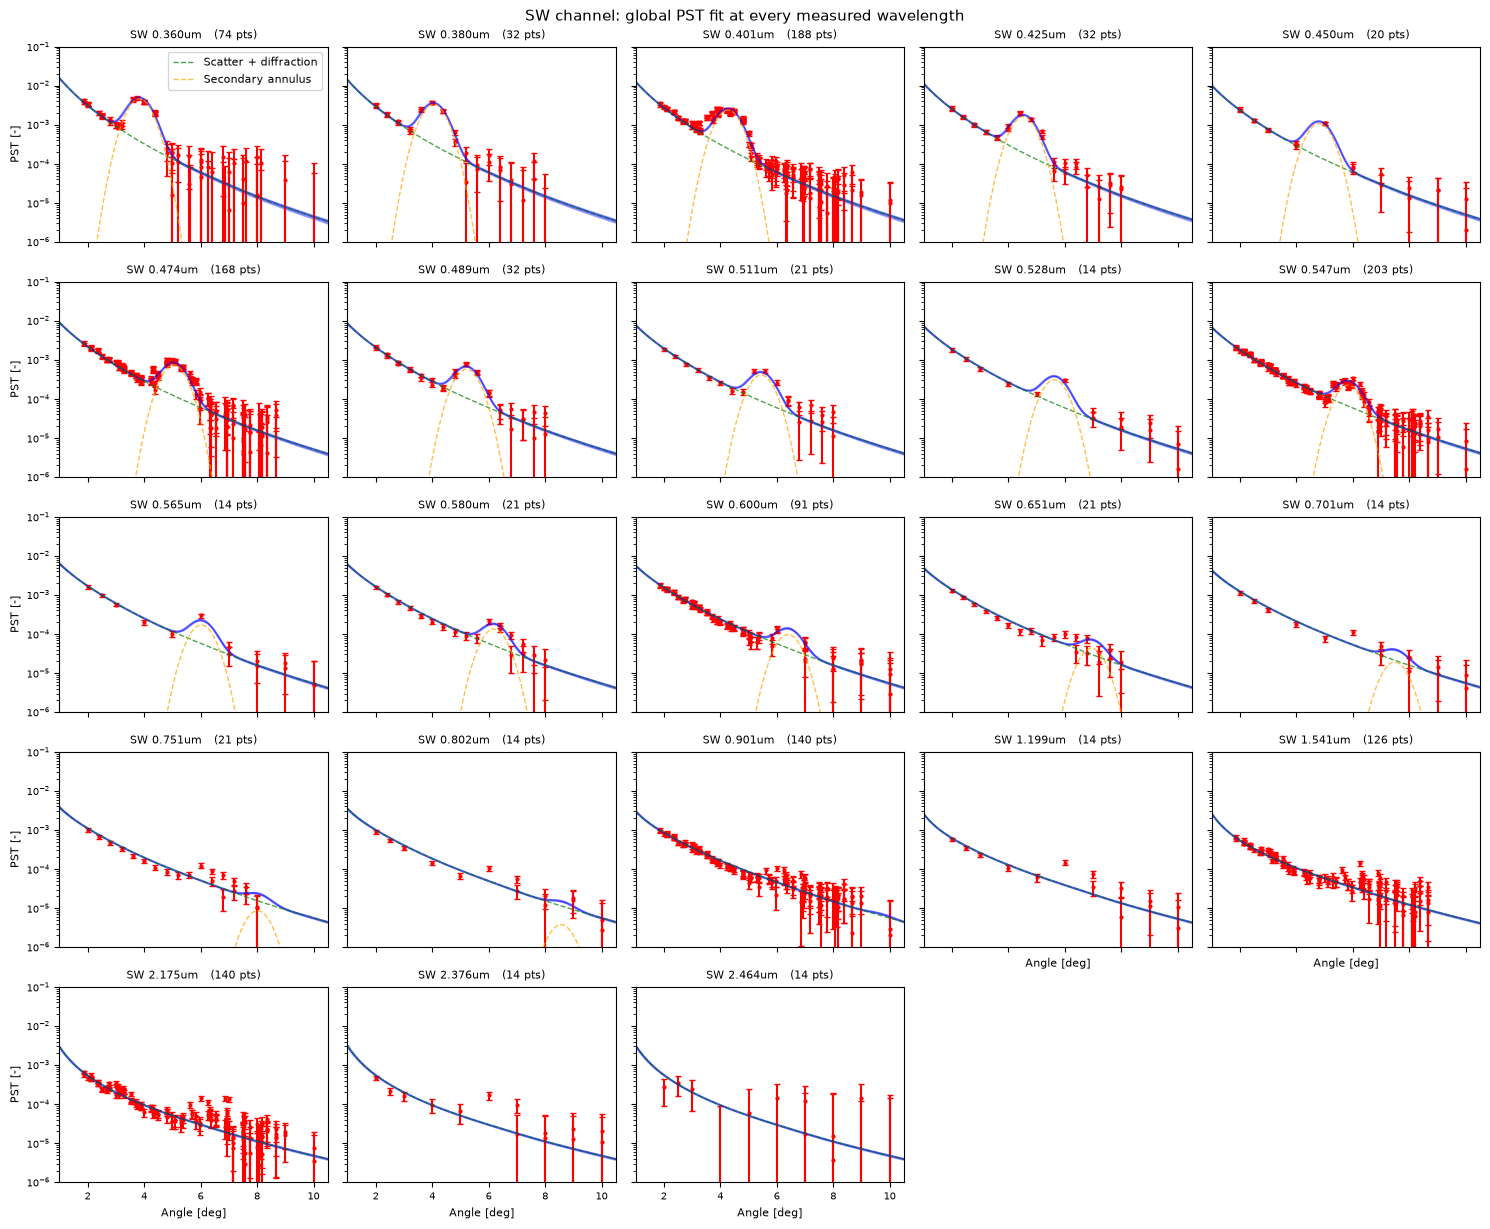

In [13]:
# Per-wavelength view of the global fit. The same panel_fn draws both the
# flipbook frames and the grid figure, so the two cannot drift apart - see
# erf_scirad_scattered_light.pst_fit_panels. The grid is the version that
# renders without a live kernel, i.e. the one visible on GitHub.
dsw.sort_values(by="wavelength_um", inplace=True)
wavelengths_um = dsw['wavelength_um'].unique()

# The angle array for fitting
angle_deg_fit = np.linspace(1,20,500)


def panel(ax, wl):
    # Get the data at this wavelength
    dtmp = dsw.loc[(dsw['wavelength_um'] == wl)].copy()
    wavelength_um = dtmp['wavelength_um'].median()

    # Calculate the fit and its uncertainty
    fit    = fit_sw.eval(angle_deg=angle_deg_fit, wavelength_um=wavelength_um)
    fit_sd = fit_sw.eval_uncertainty(angle_deg=angle_deg_fit, wavelength_um=wavelength_um)

    # Split out the ring so the annulus can be seen against the scatter
    comp = pst.pst_three_components(angle_deg_fit, wavelength_um,
                                    a0, a1, a2, lp0, lp1, gc0, gw0, gw1, ga0, ga1)

    # Plot the fit
    ax.fill_between(angle_deg_fit, fit - fit_sd, fit + fit_sd, color='blue', alpha=0.3, zorder=1)
    ax.plot(angle_deg_fit, fit, color='blue', zorder=2, alpha=0.5)
    ax.plot(angle_deg_fit, comp.pst - comp.ring, color='green', linestyle='--', linewidth=1, zorder=2, alpha=0.7, label='Scatter + diffraction')
    ax.plot(angle_deg_fit, comp.ring, color='orange', linestyle='--', linewidth=1, zorder=2, alpha=0.7, label='Secondary annulus')
    ax.errorbar(dtmp["rad_angle_deg"], dtmp["signal"], yerr=dtmp["signal_uc"],
        fmt='o', color='red', markersize=2, capsize=2, zorder=1)
    ax.set_title(f"SW {wl:4.3f}um   ({len(dtmp)} pts)")
    ax.set_xlim(1,10.5)
    ax.set_ylim(1e-6,0.1)
    ax.set_yscale('log')
    ax.legend(fontsize=8)

    return {"n_pts": len(dtmp), "l_max": dtmp['l'].max()}


series = erf_pst.pst_fit_panels(
    panel_fn       = panel,
    wavelengths_um = wavelengths_um,
    figure_dir     = paths.figure_dir,
    name_fmt       = "scirad_sw_pst_global_fit_{nm}nm.png",
    grid_name      = "scirad_sw_pst_global_fit_grid.png",
    suptitle       = "SW channel: global PST fit at every measured wavelength")

print(series.summary.to_string(index=False,
                               float_format=lambda v: f"{v:.4f}"))
erf_pst.flipbook(series.plots)

print(fit_sw.fit_report())

 wavelength_um  n_cells  excess_solid_angle_sr
         0.401       27              8.211e-08
         0.474       31              4.494e-08
         0.547       25              1.174e-08
           0.6       21              5.079e-09
         0.901       28              9.886e-09
         1.541       36              2.526e-08
         2.175       39              4.104e-08


,wavelength_um,loss_10,loss_10_sd,loss_12,loss_12_sd,loss_13,loss_13_sd
0,0.250000,19.252365,1.123701,17.579106,1.021199,14.689984,0.864623
1,0.251505,18.964332,1.097898,17.366465,1.002627,14.648781,0.854467
2,0.253020,18.678134,1.072331,17.149681,0.983964,14.595991,0.843689
3,0.254543,18.393894,1.047019,16.929248,0.965220,14.531959,0.832361
4,0.256076,18.111727,1.021980,16.705642,0.946406,14.457065,0.820551


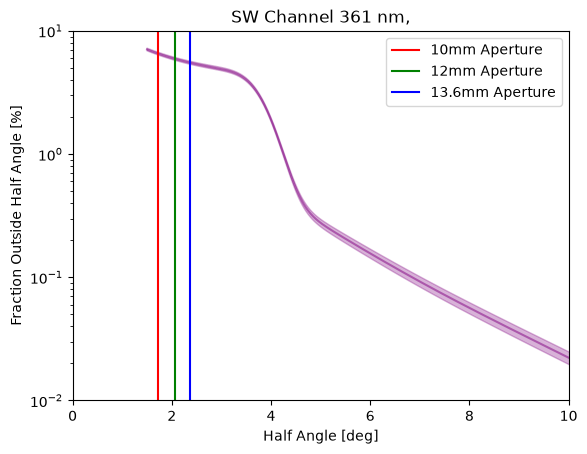

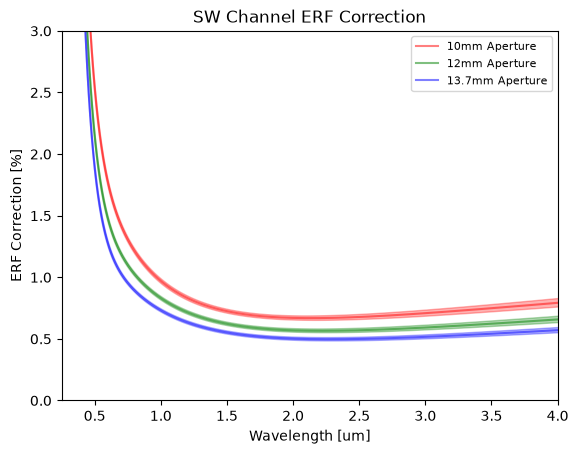

In [14]:
# Out-of-field loss vs wavelength for the sw channel.
#
# The calculation is the same for every channel, so it lives in
# erf_scirad_scattered_light.scirad_erf_correction rather than being repeated
# here: integrate the fitted PST over annular rings, add the in-field solid
# angle, and report the fraction falling outside each aperture half angle.

# Solid angle of the masked feature, measured against the baseline model. It is
# a lower bound: the feature is still rising at the +3 deg pitch travel limit.
sw_blob = erf_pst.scirad_blob_excess_solid_angle(dsw_unmasked, fit_sw)
print(sw_blob.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

loss_summary = erf_pst.scirad_erf_correction(
    fit_result         = fit_sw,
    channel            = 'sw',
    wavelength_um_min  = 0.25,
    wavelength_um_max  = 5,
    plot_wavelength_um = 0.36,
    extra_solid_angle  = sw_blob,
    summary_filename   = "scirad_sw_pst_corr.csv")

loss_summary.head()

### Correction Summary
Next we compare the corrections for the Total, SSW and SW channels. The corrections match quite well >700nm. Below 700nm there is clearly excess out of field scatter for the SW channel due to the diffraction annulus.

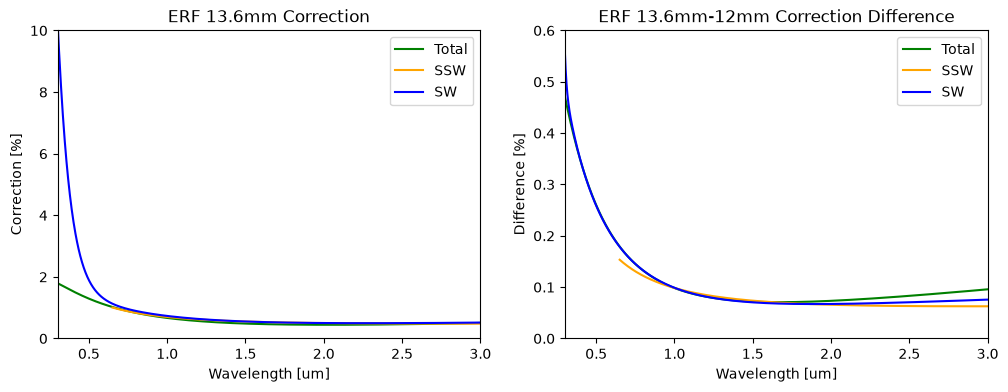

In [15]:

# Reload the corrections for each channel
paths = pst.load_config()
corr_to = erf_pst.tidy_up_header(pd.read_csv(paths.analysis_dir / "scirad_total_pst_corr.csv"))
corr_ss = erf_pst.tidy_up_header(pd.read_csv(paths.analysis_dir / "scirad_ssw_pst_corr.csv"))
corr_sw = erf_pst.tidy_up_header(pd.read_csv(paths.analysis_dir / "scirad_sw_pst_corr.csv"))

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

ax[0].plot(corr_to["wavelength_um"], corr_to["loss_13"], color='green',  label='Total')
ax[0].plot(corr_ss["wavelength_um"], corr_ss["loss_13"], color='orange', label='SSW')
ax[0].plot(corr_sw["wavelength_um"], corr_sw["loss_13"], color='blue',   label='SW')
ax[0].set_xlim(0.3,3)
ax[0].set_ylim(0,10)
ax[0].set_xlabel('Wavelength [um]')
ax[0].set_ylabel('Correction [%]')
ax[0].set_title('ERF 13.6mm Correction')
ax[0].legend()

ax[1].plot(corr_to["wavelength_um"], corr_to["loss_12"] - corr_to["loss_13"], color='green',  label='Total')
ax[1].plot(corr_ss["wavelength_um"], corr_ss["loss_12"] - corr_ss["loss_13"], color='orange', label='SSW')
ax[1].plot(corr_sw["wavelength_um"], corr_sw["loss_12"] - corr_sw["loss_13"], color='blue',   label='SW')
ax[1].set_xlim(0.3,3)
ax[1].set_ylim(0,0.6)
ax[1].set_xlabel('Wavelength [um]')
ax[1].set_ylabel('Difference [%]')
ax[1].set_title('ERF 13.6mm-12mm Correction Difference')
ax[1].legend()

## SW Channel Excess Signal Blobs
Next we plot the relative residual error for the total and SW channels. There is excess signal in the SW channel that we mask for the SW fits. We believe that this is a secondary reflection from the SW seconrady or optical filters reflecting off the fiber face. Because this signal is further from the center and over a small range of azimuth angles it contributes a small excess signal overall, but be mask is out to prevent it from impacting the fit. 

/Users/harber/Python/libera_sandbox/figures/scirad_residual_map_2175nm.png


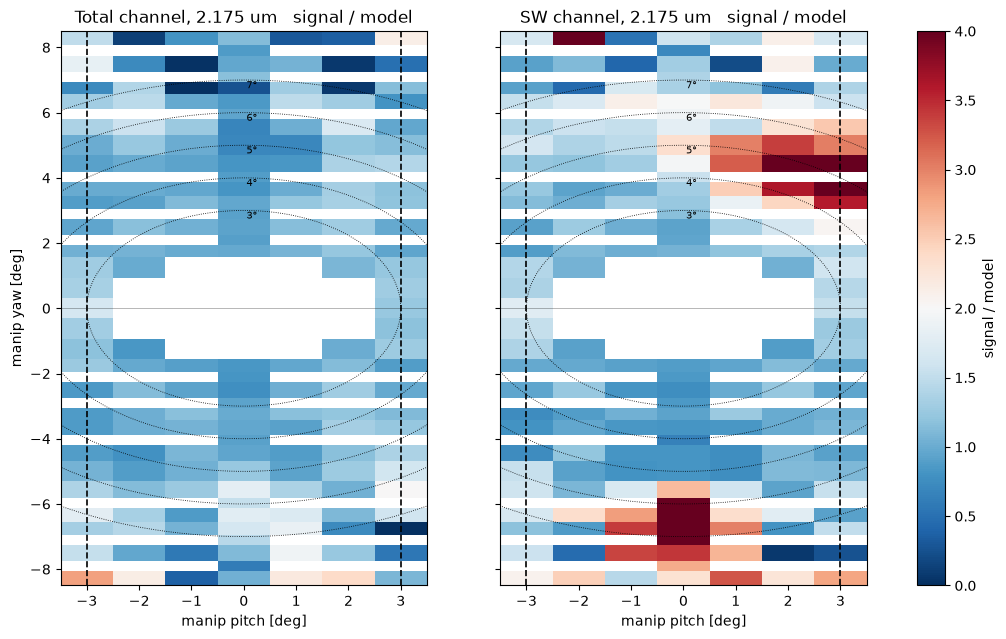

In [16]:
# Residual map over the field, for one channel and wavelength.
#
# Ratio = measured / model. A radially symmetric model leaves a map with no
# left-right structure; anything that favours one side of the field shows up
# immediately, which a plot against radial angle alone cannot reveal.

# Best-fit models come from the per-channel fits above - rto from the Total fit,
# rsw from the SW fit - rather than being refitted here.
#
# The points are reloaded unfiltered on purpose. This map exists to SHOW the
# +yaw feature, so it has to include the points apply_blob_mask removed before
# the SW fit; the model they are divided by is still the masked, uncontaminated
# fit, so the feature reads as a ratio excess rather than being absorbed.
paths = pst.load_config()
dto_pts = erf_pst.tidy_up_header(pd.read_csv(paths.analysis_dir / "scirad_total_pst_data.csv"))
dsw_pts = erf_pst.tidy_up_header(pd.read_csv(paths.analysis_dir / "scirad_sw_pst_data.csv"))

def residual_ratio(points):
    """measured / model for a set of individual points"""
    out = []
    for det, g in points.groupby('det_name'):
        if det == 'SW':
            m = pst.pst_three_components(g['rad_angle_deg'].values, g['wavelength_um'].values,
                                         rsw.a0, rsw.a1, rsw.a2, rsw.lp0, rsw.lp1,
                                         rsw.gc0, rsw.gw0, rsw.gw1, rsw.ga0, rsw.ga1).pst
        else:
            m = pst.pst_two_components(g['rad_angle_deg'].values, g['wavelength_um'].values,
                                       rto.a0, rto.a1, rto.a2, rto.lp0, rto.lp1).pst
        gg = g.copy()
        gg['model'] = m
        gg['ratio'] = gg['signal']/m
        out.append(gg)
    return pd.concat(out, ignore_index=True)

all_points = residual_ratio(pd.concat([dto_pts, dsw_pts], ignore_index=True))
all_points['pitch'] = all_points['manip_pitch_deg'].round(2)
all_points['yaw']   = all_points['manip_yaw_deg'].round(2)

# Pick the wavelength to map
plot_wavelength_um = 2.175
sel = all_points['wavelength_um'].sub(plot_wavelength_um).abs() < 1e-2

fig, axes = plt.subplots(1, 2, figsize=(13, 7.2), sharey=True)
for ax, det in zip(axes, ('Total','SW')):
    g = all_points.loc[sel & (all_points['det_name'] == det)]
    t = g.pivot_table(index='yaw', columns='pitch', values='ratio', aggfunc='mean')
    im = ax.pcolormesh(t.columns.values, t.index.values, t.values,
                       cmap='RdBu_r', vmin=0, vmax=4, shading='nearest')

    # Constant radial angle circles - a true annulus follows these all the way
    # round. Plotting both yaw halves is the point: the blob sits on one side.
    for rr in (3, 4, 5, 6, 7):
        th = np.linspace(0, 2*np.pi, 400)
        ax.plot(rr*np.cos(th), rr*np.sin(th), 'k:', lw=0.6)
        ax.annotate(f"{rr}°", (0.05, rr-0.25), fontsize=7)

    # Manipulator pitch travel limits
    ax.axvline( 3.0, color='k', ls='--', lw=1.2)
    ax.axvline(-3.0, color='k', ls='--', lw=1.2)
    ax.axhline( 0.0, color='k', lw=0.5, alpha=0.4)

    ax.set_title(f"{det} channel, {plot_wavelength_um:.3f} um   signal / model")
    ax.set_xlabel('manip pitch [deg]')
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-8.5, 8.5)

axes[0].set_ylabel('manip yaw [deg]')
fig.colorbar(im, ax=axes, label='signal / model')

plotname = paths.figure_dir / f"scirad_residual_map_{round(1000*plot_wavelength_um)}nm.png"
fig.savefig(plotname, dpi=150, bbox_inches='tight')
print(plotname)

## The SW +yaw Feature
The ratio plots above show the excess SW channel signal at about +3 Pitch, +4 Yaw. There is a second feature at about -6 Yaw, but that is at a much lower signal level and so represents a much smaller error.

The origin could not be settled. Distinguishing an telescope artifact and an scatter due to the optical source (such as reflectance from the optical bider face) could be accomlished if we repeated these measurements with the sciecne telescope flipped over. We didn't have the chance to make that measurement, and our mechaincal setup couldn't have easily accomidated it. Two things are known: the SW filter is bare fused silica with no antireflection coating, so its front-surface reflectance is nearly flat with wavelength and cannot by itself explain a feature that grows this steeply; and the same feature is at most marginally present in the Total channel, at ~1/10th the amplitude.

We decided to treat this as an artifact of the ERF light fiber light source: masked out to give an uncontaminated baseline model, with its integrated solid angle carried as an uncertainty on the correction instead of as a correction.

The feature sits at a fixed position and does not move with wavelength - it is not diffraction, which would march outward as sin(theta) proportional to lambda. Its extent is constant too, so the growth below is genuinely more light rather than the same light concentrated into a smaller spot. The amplitude is measured model-independently, as the difference between mirrored pitch positions, so the symmetric scatter cancels exactly.

Blob amplitude in peak-normalised PST units, 3-7 deg

 wavelength_um      blob      sem  centre_pitch  centre_yaw  rms_extent  sigma
         0.401 -1.22e-05 1.36e-05          1.95        3.45        1.38 -0.895
         0.474   6.9e-06 8.63e-06          1.95        4.14        1.43  0.799
         0.547  8.66e-06 4.03e-06          2.35        3.81         1.2   2.15
           0.6  1.98e-05 6.65e-06          2.26        3.38        1.21   2.98
         0.901  2.95e-05 4.75e-06          2.27        3.49        1.43    6.2
          1.54   5.3e-05 9.39e-06          2.21         3.7        1.24   5.64
          2.17  8.42e-05 1.52e-05           2.2        3.71         1.2   5.56

amplitude ~ lambda^+1.41   position and extent flat to within the scatter above
/Users/harber/Python/libera_sandbox/figures/scirad_sw_blob_amplitude.png


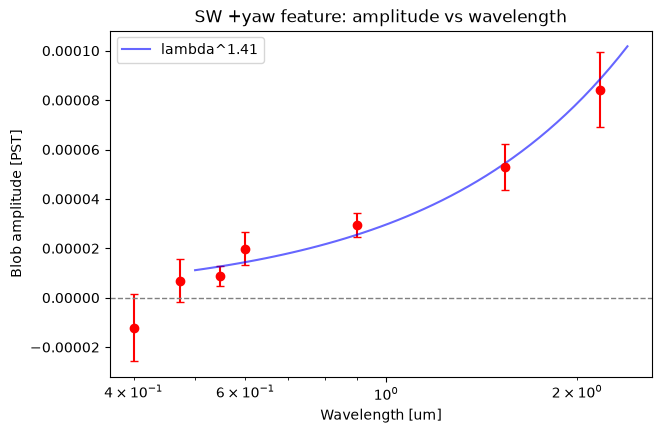

In [17]:
# Amplitude, position and extent vs wavelength.
# blob(p,y) = signal(+p,y) - signal(-p,y): the radially symmetric scatter cancels,
# so this needs no model at all.

paths = pst.load_config()
dsw_pts = erf_pst.tidy_up_header(pd.read_csv(paths.analysis_dir / "scirad_sw_pst_data.csv"))
dsw_pts['pitch'] = dsw_pts['manip_pitch_deg'].round(2)
dsw_pts['yaw']   = dsw_pts['manip_yaw_deg'].round(2)

rows = []
for wl, g in dsw_pts.loc[dsw_pts['yaw'] > 0].groupby(
                             np.round(dsw_pts['wavelength_um'], 3)):
    cell = g.groupby(['pitch', 'yaw']).agg(signal=('signal', 'mean'),
                                           r=('rad_angle_deg', 'mean'))
    diff = []
    for (pi, ya), row in cell.iterrows():
        if pi <= 0 or (-pi, ya) not in cell.index:
            continue
        if 3.0 <= np.hypot(pi, ya) <= 7.0:
            diff.append((pi, ya, row['signal'] - cell.loc[(-pi, ya), 'signal'], row['r']))
    if len(diff) < 6:
        continue
    d = pd.DataFrame(diff, columns=['p', 'y', 'blob', 'r'])
    pos = d.loc[d['blob'] > 0]
    entry = {"wavelength_um": wl,
             "blob":     d['blob'].mean(),
             "sem":      d['blob'].std(ddof=1)/np.sqrt(len(d))}
    if len(pos) >= 4:
        w = pos['blob']
        cp = np.average(pos['p'], weights=w)
        cy = np.average(pos['y'], weights=w)
        entry.update({"centre_pitch": cp, "centre_yaw": cy,
                      "rms_extent": np.sqrt(np.average((pos['p']-cp)**2 + (pos['y']-cy)**2,
                                                       weights=w))})
    rows.append(entry)

blob_amplitude = pd.DataFrame(rows)
blob_amplitude['sigma'] = blob_amplitude['blob']/blob_amplitude['sem']
print("Blob amplitude in peak-normalised PST units, 3-7 deg\n")
print(blob_amplitude.to_string(index=False, float_format=lambda v: f"{v:.3g}"))

# power law in the range where it is detected
det = blob_amplitude.loc[(blob_amplitude['wavelength_um'] > 0.5) & (blob_amplitude['blob'] > 0)]
slope = np.polyfit(np.log(det['wavelength_um']), np.log(det['blob']), 1)[0]
print(f"\namplitude ~ lambda^{slope:+.2f}   "
      f"position and extent flat to within the scatter above")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(blob_amplitude['wavelength_um'], blob_amplitude['blob'],
            yerr=blob_amplitude['sem'], fmt='o', color='red', capsize=3)
lam = np.logspace(np.log10(0.5), np.log10(2.4), 50)
ax.plot(lam, np.exp(np.polyval(np.polyfit(np.log(det['wavelength_um']),
                                          np.log(det['blob']), 1), np.log(lam))),
        color='blue', alpha=0.6, label=f'lambda^{slope:.2f}')
ax.axhline(0.0, color='grey', ls='--', lw=1)
ax.set_xscale('log')
ax.set_xlabel('Wavelength [um]')
ax.set_ylabel('Blob amplitude [PST]')
ax.set_title('SW +yaw feature: amplitude vs wavelength')
ax.legend()

plotname = paths.figure_dir / "scirad_sw_blob_amplitude.png"
fig.savefig(plotname, dpi=150, bbox_inches='tight')
print(plotname)

### Impact on the model
Masking changes the fit mainly through the particulate term, which is what carries the mid-angle signal where the feature sits. Note the reduced chi-square gets *worse* when the feature is masked: the global model drops to match the masked region and then under-predicts the surviving large-angle data. The fitted parameters are what feed the ERF correction and those behave sensibly, but the model does not describe the masked dataset as well, and there is a second unexplained structure beyond yaw 6 deg where the +yaw signal falls *below* the -yaw signal.

In [18]:
# What masking does to the fit and to the correction.
paths = pst.load_config()
dsw_pts = erf_pst.tidy_up_header(pd.read_csv(paths.analysis_dir / "scirad_sw_pst_data.csv"))
dsw_pts['pitch'] = dsw_pts['manip_pitch_deg'].round(2)
dsw_pts['yaw']   = dsw_pts['manip_yaw_deg'].round(2)

variants = {
    'unmasked':     dsw_pts,
    'blob masked':  erf_pst.apply_blob_mask(dsw_pts),
}

rows, fits = [], {}
for label, points in variants.items():
    #avg = erf_pst.scirad_average_measurements(points)
    r   = erf_pst.scirad_pst_three_component_fitting(meas_data=points)
    fits[label] = r
    rows.append({"variant": label,
                 "pct_cut": 100*(1 - len(points)/len(dsw_pts)),
                 "redchi":  r.redchi,
                 "a0": r.a0, "a1": r.a1, "a2": r.a2,
                 "lp0": r.lp0, "lp1": r.lp1})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.4g}"))

print("\nERF correction, loss_10 [%]:")
corr = {k: erf_pst.scirad_erf_correction(fit_result=v.result, channel='sw',
                                         wavelength_um_min=0.25, wavelength_um_max=5,
                                         make_plot=False)
        for k, v in fits.items()}
print(f"  {'lam':>6} " + "".join(f"{k:>14s}" for k in corr))
for wl in (0.4, 1.0, 1.5, 2.2, 3.0):
    line = f"  {wl:6.2f} "
    for k in corr:
        d = corr[k]; i = (d['wavelength_um'] - wl).abs().idxmin()
        line += f"{d.loc[i, 'loss_10']:14.3f}"
    print(line)

    variant  pct_cut  redchi     a0     a1      a2    lp0    lp1
   unmasked        0   1.976 -14.52 -2.471 -0.7239 -9.546   -2.4
blob masked    19.87   1.782 -14.48 -2.497 -0.6055 -9.807 -2.552

ERF correction, loss_10 [%]:
     lam       unmasked   blob masked
    0.40          4.718         4.755
    1.00          1.019         0.970
    1.50          0.784         0.726
    2.20          0.725         0.669
    3.00          0.752         0.709


### Excess contribution
Masking removes the feature from the fit but does not answer what it would have contributed had it been real. That is obtained by integrating the excess over the manipulator grid, using the annular element sin(theta) dpitch dyaw, and carrying the result as an uncertainty on the correction rather than as a correction.

It is a lower bound: the feature is still rising at the +3 deg pitch travel limit, so an unknown part of it lies outside the region the manipulator reaches. Even so it is tiny, because the feature is a compact patch in the wings rather than a full annulus - it subtends very little solid angle.

In [19]:
paths = pst.load_config()
dsw_pts = erf_pst.tidy_up_header(pd.read_csv(paths.analysis_dir / "scirad_sw_pst_data.csv"))
dsw_pts['pitch'] = dsw_pts['manip_pitch_deg'].round(2)
dsw_pts['yaw']   = dsw_pts['manip_yaw_deg'].round(2)

variants = {
    'unmasked':     dsw_pts,
    'blob masked':  erf_pst.apply_blob_mask(dsw_pts),
}

# Integrated excess solid angle, and what it does to the reported uncertainty.
baseline = erf_pst.scirad_pst_three_component_fitting(
               meas_data=erf_pst.apply_blob_mask(dsw_pts))

sw_blob = erf_pst.scirad_blob_excess_solid_angle(dsw_pts, baseline.result)

conv = erf.get_scirad_conversions(fpe_name='fmfpe')
sw_blob['pct_of_correction'] = 100*sw_blob['excess_solid_angle_sr']/conv.loc['sw', 'solid_angle']
print("Excess solid angle of the masked feature (lower bound)\n")
print(sw_blob.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

without = erf_pst.scirad_erf_correction(fit_result=baseline.result, channel='sw',
                                        wavelength_um_min=0.25, wavelength_um_max=5,
                                        make_plot=False)
with_    = erf_pst.scirad_erf_correction(fit_result=baseline.result, channel='sw',
                                         wavelength_um_min=0.25, wavelength_um_max=5,
                                         extra_solid_angle=sw_blob, make_plot=False)

print("\nEffect on the reported uncertainty of the correction:")
print(f"  {'lam':>6} {'loss_10':>9} {'sd (fit only)':>14} {'sd (+blob)':>11} {'increase':>9}")
for wl in (0.4, 1.0, 2.2, 3.0, 5.0):
    i = (without['wavelength_um'] - wl).abs().idxmin()
    a = without.loc[i, 'loss_10_sd']; b = with_.loc[i, 'loss_10_sd']
    print(f"  {wl:6.2f} {without.loc[i, 'loss_10']:9.4f} {a:14.4f} {b:11.4f} "
          f"{100*(b/a - 1):8.2f}%")

print("\nThe feature is a few percent of the existing uncertainty and well under")
print("one percent of the correction itself, so masking it costs almost nothing.")

Excess solid angle of the masked feature (lower bound)

 wavelength_um  n_cells  excess_solid_angle_sr  pct_of_correction
         0.401       27              8.211e-08            0.01073
         0.474       31              4.494e-08           0.005871
         0.547       25              1.174e-08           0.001533
           0.6       21              5.079e-09          0.0006635
         0.901       28              9.886e-09           0.001291
         1.541       36              2.526e-08             0.0033
         2.175       39              4.104e-08           0.005361

Effect on the reported uncertainty of the correction:
     lam   loss_10  sd (fit only)  sd (+blob)  increase
    0.40    4.7546         0.0970      0.0976     0.60%
    1.00    0.9703         0.0189      0.0190     0.34%
    2.20    0.6689         0.0178      0.0186     4.45%
    3.00    0.7089         0.0244      0.0250     2.38%
    5.00    0.8822         0.0446      0.0449     0.72%

The feature is a few per